In [1]:
import toml
from analysis import Analysis
#from analysis_syst import Analysis



/Users/danielcarber/Documents/ICARUS/NuMI_Nue/develop_branches/medulla_NuMI_plotting/spineplot/systematic.py:203: RuntimeWarning: invalid value encountered in scalar divide
  self._std /= histogram.sum()


--Systematic(GENIEReWeight_SBN_v1_multisim_ZExpAVariationResponse, None)--
	Fractional uncertainty: 8.54%
--Systematic(GENIEReWeight_SBN_v1_multisim_RPA_CCQE, None)--
	Fractional uncertainty: 1.13%
--Systematic(GENIEReWeight_SBN_v1_multisim_CoulombCCQE, None)--
	Fractional uncertainty: 0.28%
--Systematic(GENIEReWeight_SBN_v1_multisim_NormCCMEC, None)--
	Fractional uncertainty: 9.61%
--Systematic(GENIEReWeight_SBN_v1_multisim_NormNCMEC, None)--
	Fractional uncertainty: 0.00%
--Systematic(GENIEReWeight_SBN_v1_multisim_NCELVariationResponse, None)--
	Fractional uncertainty: 0.00%
--Systematic(GENIEReWeight_SBN_v1_multisim_CCRESVariationResponse, None)--
	Fractional uncertainty: 4.06%
--Systematic(GENIEReWeight_SBN_v1_multisim_NCRESVariationResponse, None)--
	Fractional uncertainty: 0.92%
--Systematic(GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC1pi, None)--
	Fractional uncertainty: 0.00%
--Systematic(GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC2pi, None)--
	Fractional uncertainty: 0.04%
--Syst

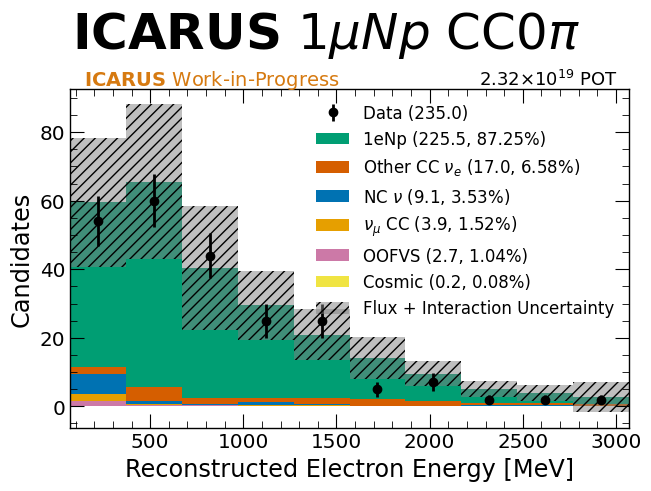

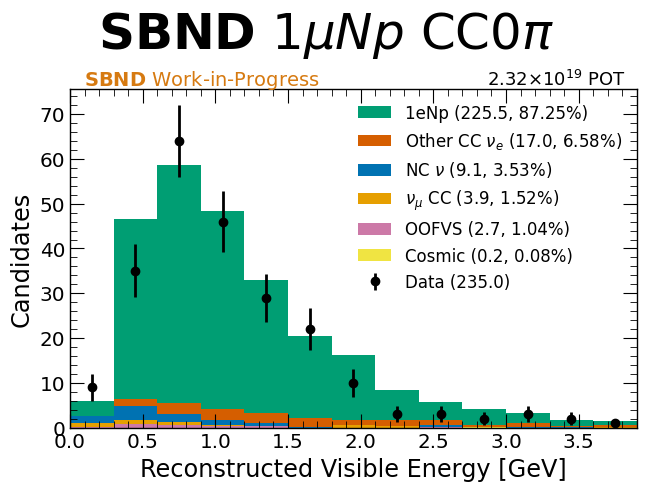

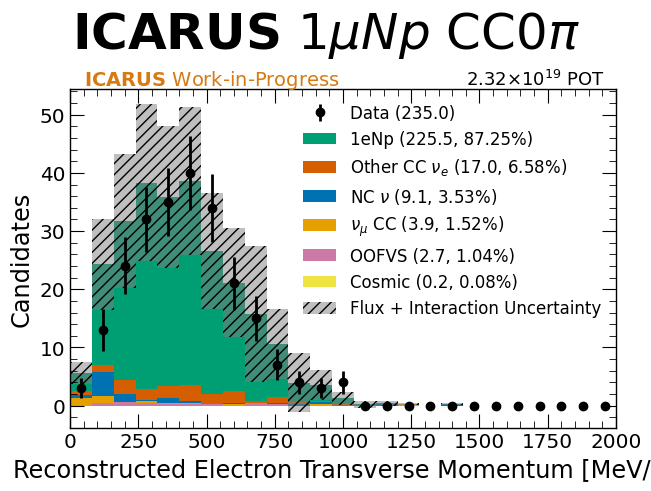

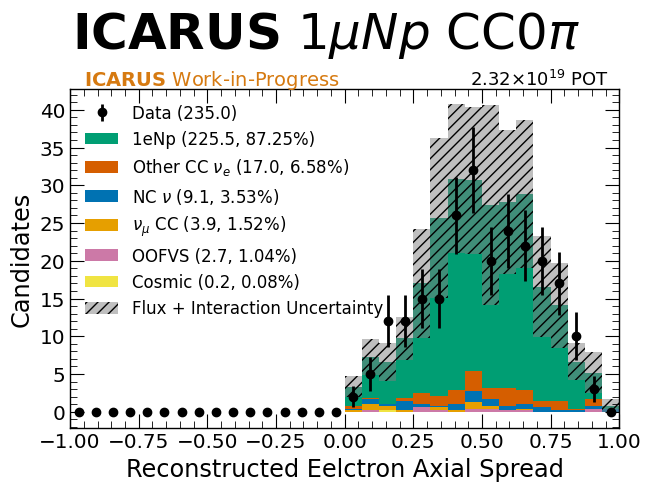

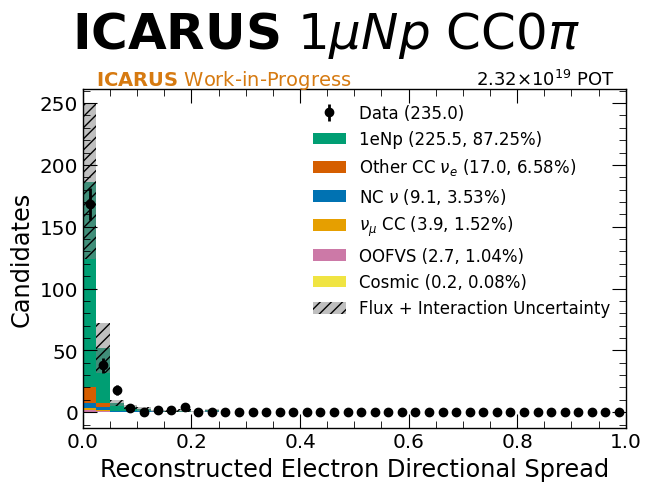

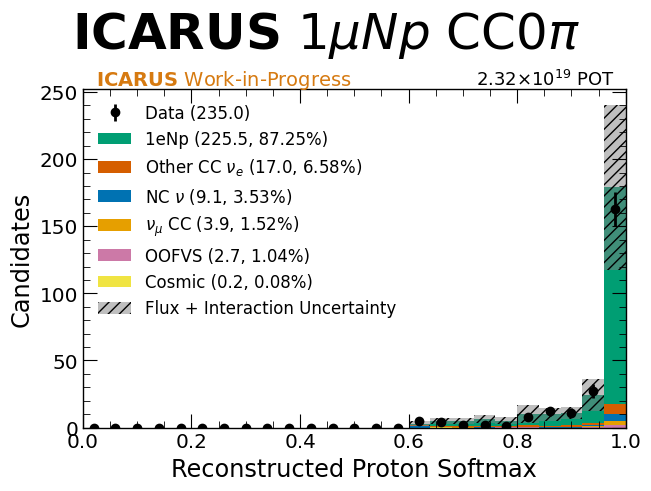

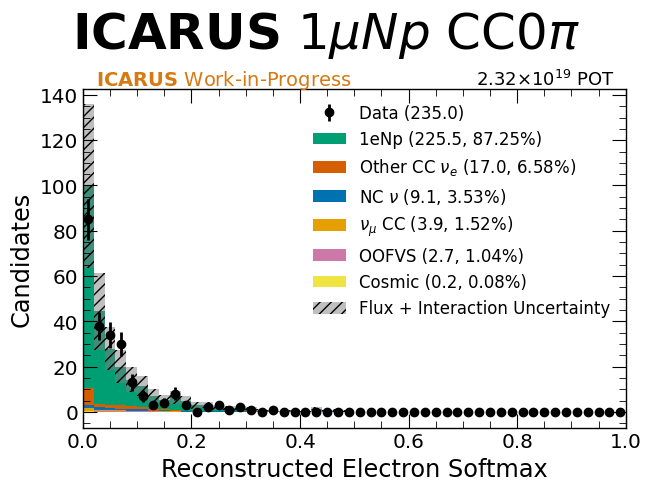

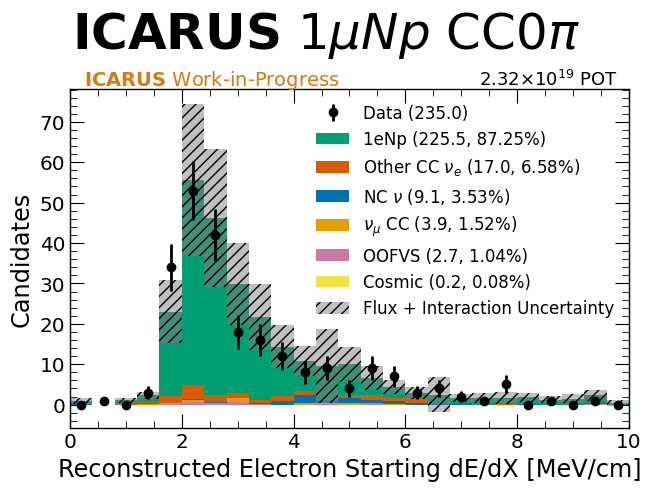

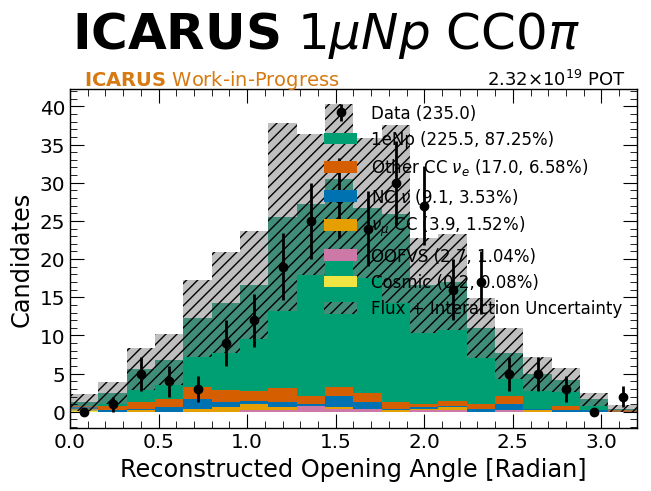

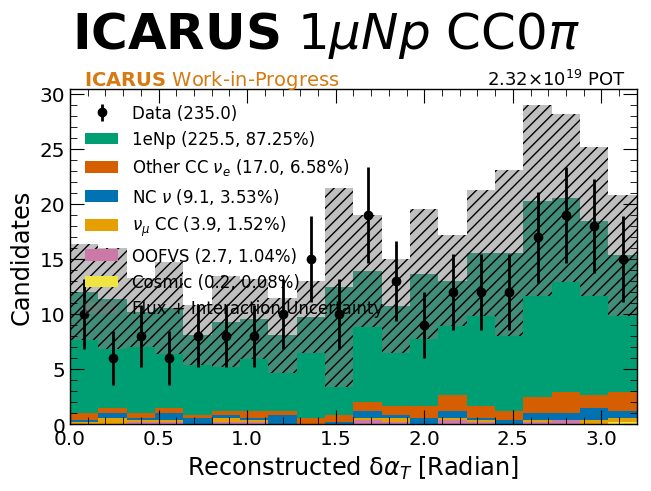

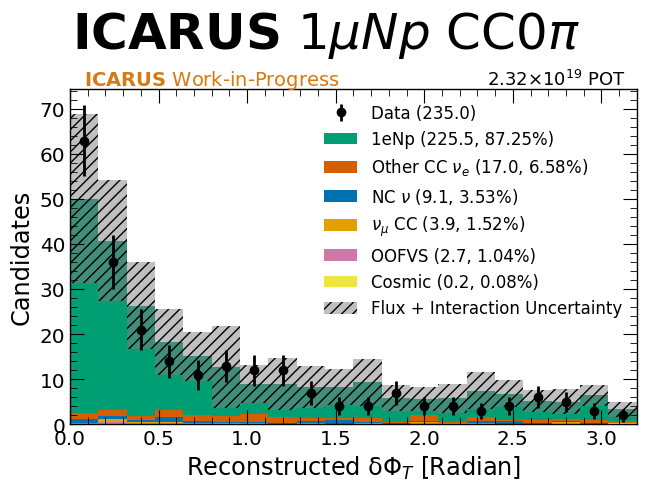

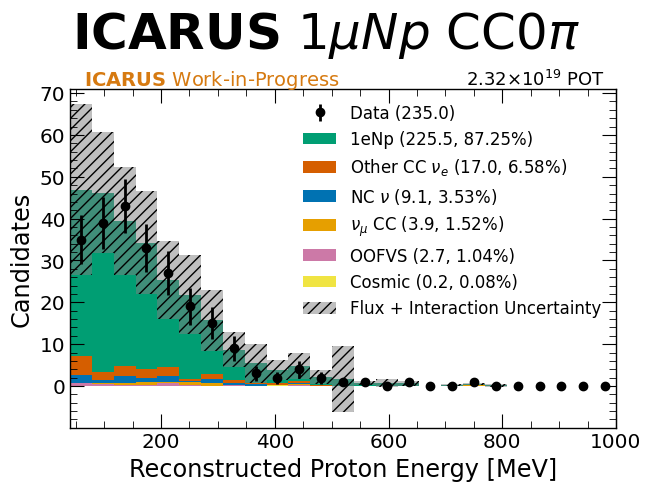

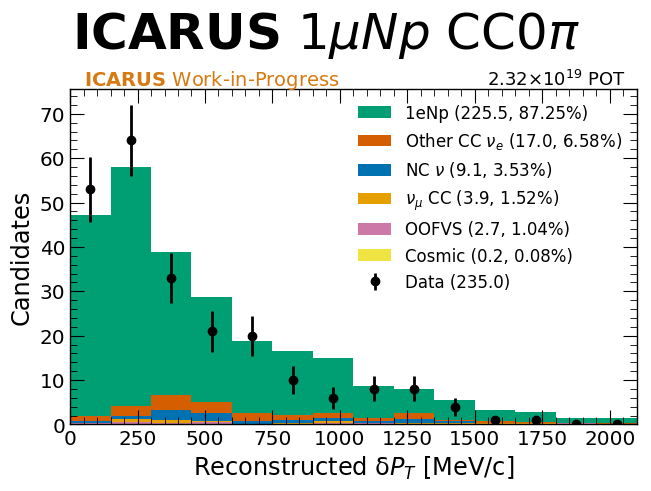

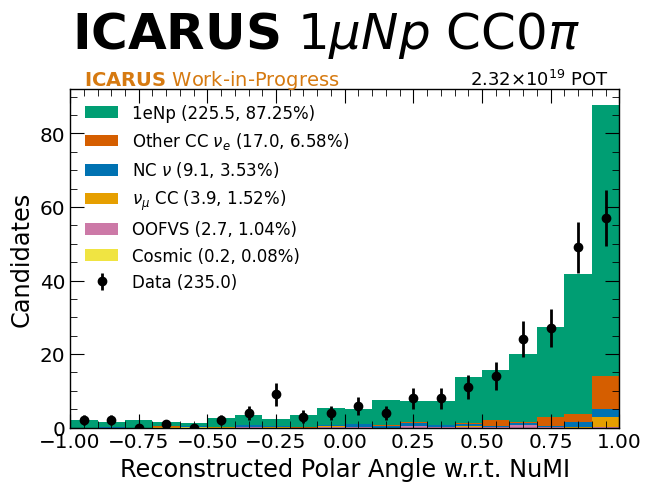

In [3]:
cfg = """
[[this_includes]]
file = 'configurations/analyses/icarus/nue2025_icarus.toml'

[[this_includes]]
file = 'configurations/common/styles.toml'

[samples]
[samples.onbeam]
key = "onbeam"
exposure_type = "pot"
override_category = -100
trees = ['SelectedNu_PhaseCuts',]
#presel = "flash_time > -1.3 and flash_time < 0.5"
[samples.offbeam]
key = "offbeam"
exposure_type = "Livetime"
override_category = -1
trees = ['SelectedCos_PhaseCuts',]
#print_sys = true
[samples.mc_nu]
key = "mc"
exposure_type = "pot"
trees = ['SelectedNu_Cuts']
presel = 'matches_baseline == 1'
systematics = ['multisimTree','multisigmaTree']
print_sys = true
[samples.mc_cos]
key = "mc"
exposure_type = "pot"
trees = ['SelectedCos_PhaseCuts']
#presel = "flash_time > 0.2 and flash_time < 2.0"
#presel = 'matches_baseline == 1'
#systematics = ['multisigmaTree']
#[samples.mc]
#key = "mc"
#exposure_type = "pot"
#trees = ['SelectedNu_Cuts','SelectedCos_PhaseCuts']



[output]
path = '/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots'

[[systematic_recipe]]
name = 'flux'
label = 'Flux Systematics'
#pattern = '_Flux'
pattern = '\\b\\w*_Flux\\b'

[[systematic_recipe]]
name = 'xsec'
label = 'Interaction Systematics'
pattern = '\\bGENIEReWeight_SBN_v1_multisigma_\\w+\\b'
#pattern = 'GENIEReWeight_SBN_v1_multisim'


[[systematic_recipe]]
name = 'stats'
label = 'Statistical Uncertainty'
#pattern = 'mc_statistical'
pattern = '(mc_nu|mc_cos)_statistical'
#pattern = '(mc|offbeam)_statistical'

#[[systematic_recipe]]
#name = 'offbeam_stats'
#label = 'Statistical Uncertainty'
#pattern = 'mc_statistical'
#pattern = '(mc_nu|mc_cos|offbeam)_statistical'
#pattern = '(offbeam)_statistical'

#[[systematic_recipe]]
#name = 'MC_stats'
#label = 'Statistical Uncertainty'
#pattern = 'mc_statistical'
#pattern = '(mc_nu|mc_cos)_statistical'
#pattern = '(offbeam)_statistical'

[[systematic_recipe]]
name = 'flux_xsec'
label = 'Flux + Interaction Uncertainty'
pattern = '(flux|xsec|stats)'
                
#[[systematic_recipe]]
#name = 'all'
#label = 'Total MC Uncertainty'
#pattern = '(flux|xsec|stats)'
#pattern = '(detsys|flux|xsec|stats)'


[analysis]
ordinate_sample = 'onbeam'
category_branch = 'category_topology'
category_assignment = [[0,1], [2,3,4,6], [5], [7],[8],[9],[11,-1], [-100]]
category_labels = ['1eNp', 'Other CC $\\nu_e$', 'NC $\\nu$', '$\\nu_\\mu$ CC','OOFVS','Other','Cosmic', 'Data']
category_colors = ['C0', 'C1', 'C3', 'C4', 'C5','C6','C7','black']
category_types = ['histogram', 'histogram', 'histogram', 'histogram', 'histogram','histogram', 'histogram', 'scatter']


[[figure]]
name = 'reco_electron_energy'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_energy','yrange' = [70, 3000],'draw_kwargs' = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_electron_energy'
#yrange = [0, 1000]
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true,'draw_error' = 'flux_xsec'}#

[[figure]]
name = 'reco_visible_energy'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_energy','yrange' = [70, 3000],'draw_kwargs' = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}},]
style = 'selected_sbnd'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_visible_energy'
#yrange = [0, 1000]
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true}#, 'draw_error' = 'flux_xsec'


[[figure]]
name = 'reco_electron_pT_mag'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_pT_mag'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_electron_pT_mag'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

#[[figure]]
#name = 'reco_electron_conv_dist'
#type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_conv_dist'},]
#style = 'selected_icarus'
#[[figure.artists]]
#type = 'SpineSpectra1D'
#variable = 'reco_electron_conv_dist'
#draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_electron_axial_spread'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_axial_spread'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_electron_axial_spread'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_electron_dir_spread'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_dir_spread'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_electron_dir_spread'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_proton_softmax'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_proton_softmax'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_proton_softmax'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}
[[figure]]
name = 'reco_electron_softmax'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_softmax'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_electron_softmax'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_electron_dedx'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_dedx'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_electron_dedx'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_opening_angle'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_opening_angle'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_opening_angle'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_dalphaT'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_dalphaT'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_dalphaT'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_dphiT'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_dphiT'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_dphiT'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}

[[figure]]
name = 'reco_proton_energy'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_proton_energy'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_proton_energy'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true, 'draw_error' = 'flux_xsec'}
[[figure]]
name = 'reco_dpT'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_dpT'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_dpT'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true}#, 'draw_error' = 'flux_xsec'

[[figure]]
name = 'reco_electron_polar'
type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_electron_polar'},]
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'reco_electron_polar'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true}#, 'draw_error' = 'flux_xsec'


#[[figure]]
#name = 'reco_dpT_lp'
#type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'reco_dpT_lp'},]
#style = 'selected_icarus'
#[[figure.artists]]
#type = 'SpineSpectra1D'
#variable = 'reco_dpT_lp'
#draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true}#, 'draw_error' = 'flux_xsec'

#[[figure]]
#name = 'true_dpT'
#type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'true_dpT'},]
#style = 'selected_icarus'
#[[figure.artists]]
#type = 'SpineSpectra1D'
#variable = 'true_dpT'
#draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true}#, 'draw_error' = 'flux_xsec'

#[[figure]]
#name = 'true_dpT_lp'
#type = 'SimpleFigure'
#artists = [{'type' = 'SpineSpectra1D', 'variable' = 'true_dpT_lp'},]
#style = 'selected_icarus'
#[[figure.artists]]
#type = 'SpineSpectra1D'
#variable = 'true_dpT_lp'
#draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = true}#, 'draw_error' = 'flux_xsec'

"""
# Write the string to a file
with open('cfg.toml', 'w') as f:
    f.write(cfg)

file = '/Users/danielcarber/Documents/ICARUS/full_syst.root'

analysis = Analysis('cfg.toml', file)
#analysis.override_exposure('onbeam',1,'pot')
analysis.run(close_figs=False)